# Phase 5 : Tests Statistiques
## Système d'Aide à la Décision — Fidélisation Client E-commerce

---
**Objectif :** Valider les hypothèses métier à travers des tests statistiques rigoureux.
Chaque test répond à une sous-question décisionnelle du projet.

---

## 5.1 - Imports et Chargement des Données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import (
    ttest_ind,       # T-Test independant (2 groupes)
    mannwhitneyu,    # Mann-Whitney U (non parametrique)
    chi2_contingency,# Chi-Square (variables categoriques)
    f_oneway,        # ANOVA (3+ groupes)
    kruskal          # Kruskal-Wallis (ANOVA non parametrique)
)
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

# Seuil de significativite statistique standard
ALPHA = 0.05

print('\u2713 Librairies import\u00e9es')
print(f'  Seuil alpha : {ALPHA}')

✓ Librairies importées
  Seuil alpha : 0.05


In [2]:
# ===========================================================
# CHEMINS
# ===========================================================
BASE_PATH  = r"C:\Users\AORUS\Documents\ENSIAS 2A\projetDDD"
OLIST_PATH = BASE_PATH + r"\Brazilian E-Commerce Public Dataset by Olist"

# Chargement du dataset analytique final (produit en Phase 3)
ca = pd.read_csv('customer_analytics.csv')
ca['first_order_date'] = pd.to_datetime(ca['first_order_date'])
ca['last_order_date']  = pd.to_datetime(ca['last_order_date'])

# Rechargement des tables brutes necessaires
olist_orders      = pd.read_csv(f"{OLIST_PATH}/olist_orders_dataset.csv")
olist_order_items = pd.read_csv(f"{OLIST_PATH}/olist_order_items_dataset.csv")
olist_payments    = pd.read_csv(f"{OLIST_PATH}/olist_order_payments_dataset.csv")
olist_reviews     = pd.read_csv(f"{OLIST_PATH}/olist_order_reviews_dataset.csv")
olist_products    = pd.read_csv(f"{OLIST_PATH}/olist_products_dataset.csv")
olist_category    = pd.read_csv(f"{OLIST_PATH}/product_category_name_translation.csv")

# Conversion des dates
date_cols = [
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    olist_orders[col] = pd.to_datetime(olist_orders[col], errors='coerce')

# Preparation dataset commandes livrees
orders_delivered = olist_orders[olist_orders['order_status'] == 'delivered'].copy()

# Variables de livraison
orders_delivered['delivery_delay_days'] = (
    orders_delivered['order_delivered_customer_date'] -
    orders_delivered['order_estimated_delivery_date']
).dt.days

orders_delivered['actual_delivery_days'] = (
    orders_delivered['order_delivered_customer_date'] -
    orders_delivered['order_purchase_timestamp']
).dt.days

orders_delivered['is_late'] = (orders_delivered['delivery_delay_days'] > 0).astype(int)
orders_delivered = orders_delivered.dropna(
    subset=['delivery_delay_days', 'actual_delivery_days']
)

# Jointure avec avis
olist_reviews_clean = olist_reviews.dropna(subset=['review_score']).copy()
olist_reviews_clean['review_score'] = olist_reviews_clean['review_score'].astype(int)
olist_reviews_clean = olist_reviews_clean[olist_reviews_clean['review_score'].between(1, 5)]

orders_with_reviews = orders_delivered.merge(
    olist_reviews_clean[['order_id', 'review_score']],
    on='order_id', how='inner'
)

# Jointure avec categories produits
items_products = olist_order_items.merge(
    olist_products[['product_id', 'product_category_name']], on='product_id', how='left'
)
items_products = items_products.merge(olist_category, on='product_category_name', how='left')
orders_with_category = orders_with_reviews.merge(
    items_products[['order_id', 'product_category_name_english']].drop_duplicates('order_id'),
    on='order_id', how='left'
)

print('\u2713 Donn\u00e9es charg\u00e9es et pr\u00e9par\u00e9es')
print(f'  customer_analytics   : {ca.shape[0]:,} clients')
print(f'  orders_with_reviews  : {orders_with_reviews.shape[0]:,} commandes')
print(f'  orders_with_category : {orders_with_category.shape[0]:,} commandes')

✓ Données chargées et préparées
  customer_analytics   : 93,350 clients
  orders_with_reviews  : 96,353 commandes
  orders_with_category : 96,353 commandes


## 5.2 - Fonction Utilitaire : Interprétation des Tests

In [4]:
# =============================================================
# FONCTION UTILITAIRE : affiche le resultat d'un test proprement
# =============================================================
def print_test_result(test_name, statistic, p_value, alpha=0.05,
                      h0='', h1='', extra_info=None):
    """
    Affiche le resultat d'un test statistique de facon lisible.

    Parametres:
        test_name  : Nom du test (str)
        statistic  : Valeur de la statistique de test
        p_value    : p-value obtenue
        alpha      : Seuil de significativite (defaut 0.05)
        h0         : Hypothese nulle (str)
        h1         : Hypothese alternative (str)
        extra_info : dict optionnel avec infos supplementaires
    """
    decision  = 'REJETER H0' if p_value < alpha else 'NE PAS REJETER H0'
    icon      = '\u2713' if p_value < alpha else '\u2717'
    sig_label = 'Significatif' if p_value < alpha else 'Non significatif'

    print('\n' + '=' * 65)
    print(f'  TEST : {test_name}')
    print('=' * 65)
    if h0:
        print(f'  H0 : {h0}')
    if h1:
        print(f'  H1 : {h1}')
    print(f'  Statistique : {statistic:.4f}')
    print(f'  p-value     : {p_value:.6f}')
    print(f'  Seuil alpha : {alpha}')
    print(f'  Decision    : {icon} {decision} ({sig_label})')
    if extra_info:
        for k, v in extra_info.items():
            print(f'  {k}: {v}')
    print('=' * 65)


# Tableau de resultats global (rempli au fur et a mesure)
results_table = []

print('\u2713 Fonction print_test_result definie')

✓ Fonction print_test_result definie


## 5.3 - Test 1 : Le retard de livraison influence-t-il la satisfaction ?

**Type :** T-Test + Mann-Whitney U  
**Variable dependante :** `review_score`  
**Variable independante :** `is_late` (0 = a temps, 1 = en retard)

In [5]:
# =============================================================
# PREPARATION DES GROUPES
# Groupe A : commandes livrees a temps ou en avance
# Groupe B : commandes livrees en retard
# =============================================================
group_ontime = orders_with_reviews[orders_with_reviews['is_late'] == 0]['review_score']
group_late   = orders_with_reviews[orders_with_reviews['is_late'] == 1]['review_score']

print('Statistiques descriptives par groupe :')
print(f'  A temps  : n={len(group_ontime):,}  moyenne={group_ontime.mean():.3f}  std={group_ontime.std():.3f}')
print(f'  En retard: n={len(group_late):,}  moyenne={group_late.mean():.3f}  std={group_late.std():.3f}')
print(f'  Difference moyenne: {group_ontime.mean() - group_late.mean():.3f} points')

Statistiques descriptives par groupe :
  A temps  : n=89,944  moyenne=4.290  std=1.150
  En retard: n=6,409  moyenne=2.271  std=1.571
  Difference moyenne: 2.019 points


In [6]:
# =============================================================
# TEST DE NORMALITE (Shapiro-Wilk sur echantillon)
# Shapiro-Wilk est fiable jusqu'a ~5000 observations
# =============================================================
sample_ontime = group_ontime.sample(min(1000, len(group_ontime)), random_state=42)
sample_late   = group_late.sample(min(1000, len(group_late)), random_state=42)

stat_norm_a, p_norm_a = stats.shapiro(sample_ontime)
stat_norm_b, p_norm_b = stats.shapiro(sample_late)

print('Test de normalite Shapiro-Wilk (echantillon 1000) :')
print(f'  Groupe A temps  : W={stat_norm_a:.4f}, p={p_norm_a:.6f} -> {"Non normal" if p_norm_a < ALPHA else "Normal"}')
print(f'  Groupe En retard: W={stat_norm_b:.4f}, p={p_norm_b:.6f} -> {"Non normal" if p_norm_b < ALPHA else "Normal"}')
print('\n  => Les distributions ne sont pas normales (variable discrete 1-5)')
print('     On utilisera Mann-Whitney U comme test principal.')

Test de normalite Shapiro-Wilk (echantillon 1000) :
  Groupe A temps  : W=0.6566, p=0.000000 -> Non normal
  Groupe En retard: W=0.7600, p=0.000000 -> Non normal

  => Les distributions ne sont pas normales (variable discrete 1-5)
     On utilisera Mann-Whitney U comme test principal.


In [7]:
# =============================================================
# T-TEST INDEPENDANT
# Robuste aux grands echantillons meme sans normalite (TCL)
# =============================================================
t_stat, t_pval = ttest_ind(group_ontime, group_late, equal_var=False)

print_test_result(
    test_name = 'T-Test de Welch (retard vs satisfaction)',
    statistic = t_stat,
    p_value   = t_pval,
    alpha     = ALPHA,
    h0        = 'La moyenne des notes est identique entre commandes a temps et en retard',
    h1        = 'Les commandes en retard ont une note moyenne significativement differente',
    extra_info= {
        'Moyenne A temps'  : f'{group_ontime.mean():.3f}',
        'Moyenne En retard': f'{group_late.mean():.3f}'
    }
)

results_table.append({
    'Hypothese'  : 'Retard -> Satisfaction (T-Test)',
    'Statistique': round(t_stat, 4),
    'p-value'    : round(t_pval, 6),
    'Decision'   : 'Rejeter H0' if t_pval < ALPHA else 'Ne pas rejeter H0',
    'Significatif': 'Oui' if t_pval < ALPHA else 'Non'
})


  TEST : T-Test de Welch (retard vs satisfaction)
  H0 : La moyenne des notes est identique entre commandes a temps et en retard
  H1 : Les commandes en retard ont une note moyenne significativement differente
  Statistique : 100.9655
  p-value     : 0.000000
  Seuil alpha : 0.05
  Decision    : ✓ REJETER H0 (Significatif)
  Moyenne A temps: 4.290
  Moyenne En retard: 2.271


In [8]:
# =============================================================
# MANN-WHITNEY U (non parametrique — plus adapte ici)
# Test sur les rangs, ne suppose pas la normalite
# =============================================================
mw_stat, mw_pval = mannwhitneyu(group_ontime, group_late, alternative='two-sided')

print_test_result(
    test_name = 'Mann-Whitney U (retard vs satisfaction)',
    statistic = mw_stat,
    p_value   = mw_pval,
    alpha     = ALPHA,
    h0        = 'Les distributions des notes sont identiques entre les deux groupes',
    h1        = 'Les distributions des notes different significativement entre les groupes'
)

results_table.append({
    'Hypothese'  : 'Retard -> Satisfaction (Mann-Whitney)',
    'Statistique': round(mw_stat, 4),
    'p-value'    : round(mw_pval, 6),
    'Decision'   : 'Rejeter H0' if mw_pval < ALPHA else 'Ne pas rejeter H0',
    'Significatif': 'Oui' if mw_pval < ALPHA else 'Non'
})


  TEST : Mann-Whitney U (retard vs satisfaction)
  H0 : Les distributions des notes sont identiques entre les deux groupes
  H1 : Les distributions des notes different significativement entre les groupes
  Statistique : 472044142.0000
  p-value     : 0.000000
  Seuil alpha : 0.05
  Decision    : ✓ REJETER H0 (Significatif)



Taille d'effet (Cohen's d) : 1.4666 (Fort)


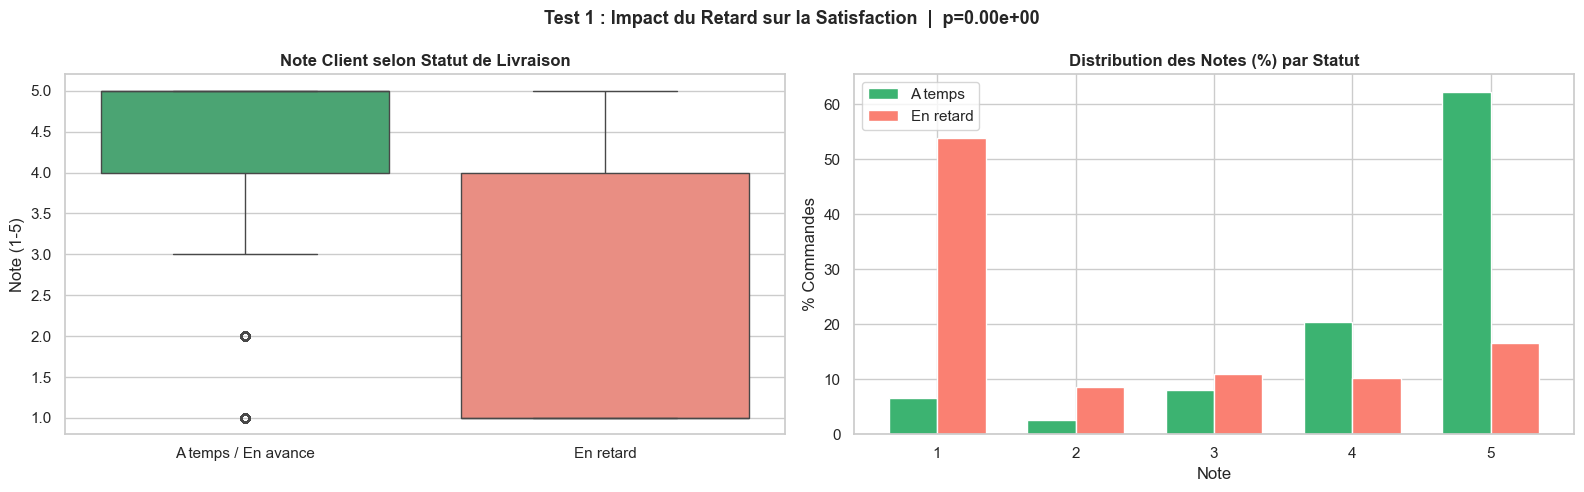

✓ test1_retard_satisfaction.png sauvegardé


In [9]:
# =============================================================
# TAILLE D'EFFET — Cohen's d
# Mesure l'ampleur pratique de la difference, pas juste sa significativite
# |d| < 0.2 = faible | 0.2-0.5 = modere | > 0.5 = fort
# =============================================================
pooled_std = np.sqrt(
    (group_ontime.std()**2 + group_late.std()**2) / 2
)
cohens_d = (group_ontime.mean() - group_late.mean()) / pooled_std

interpretation = 'Faible' if abs(cohens_d) < 0.2 else ('Modere' if abs(cohens_d) < 0.5 else 'Fort')
print(f'\nTaille d\'effet (Cohen\'s d) : {cohens_d:.4f} ({interpretation})')

# =============================================================
# VISUALISATION : distribution des notes selon le statut de livraison
# =============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Boxplot
orders_with_reviews['statut'] = orders_with_reviews['is_late'].map(
    {0: 'A temps / En avance', 1: 'En retard'}
)
sns.boxplot(
    data=orders_with_reviews, x='statut', y='review_score',
    palette={'A temps / En avance': 'mediumseagreen', 'En retard': 'salmon'},
    ax=axes[0]
)
axes[0].set_title('Note Client selon Statut de Livraison', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Note (1-5)')

# Distribution des notes par groupe (barres cote a cote)
notes_pivot = pd.DataFrame({
    'A temps'  : group_ontime.value_counts(normalize=True).sort_index() * 100,
    'En retard': group_late.value_counts(normalize=True).sort_index() * 100
})
notes_pivot.plot(kind='bar', ax=axes[1], color=['mediumseagreen', 'salmon'],
                 edgecolor='white', width=0.7)
axes[1].set_title('Distribution des Notes (%) par Statut', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Note')
axes[1].set_ylabel('% Commandes')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend()

plt.suptitle(f'Test 1 : Impact du Retard sur la Satisfaction  |  p={mw_pval:.2e}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/test1_retard_satisfaction.png", dpi=150, bbox_inches='tight')
plt.show()
print('\u2713 test1_retard_satisfaction.png sauvegard\u00e9')

## 5.4 - Test 2 : La catégorie produit influence-t-elle la satisfaction ?

**Type :** Chi-Square + ANOVA + Kruskal-Wallis  
**Variable dependante :** `review_score`  
**Variable independante :** `product_category_name_english`

In [10]:
# =============================================================
# PREPARATION : top categories avec assez d'observations
# On garde les categories avec au moins 200 commandes
# =============================================================
cat_counts = orders_with_category['product_category_name_english'].value_counts()
top_cats   = cat_counts[cat_counts >= 200].index.tolist()

orders_top_cats = orders_with_category[
    orders_with_category['product_category_name_english'].isin(top_cats)
].copy()

print(f'Categories retenues (>= 200 commandes) : {len(top_cats)}')
print(f'Commandes dans ces categories          : {orders_top_cats.shape[0]:,}')

Categories retenues (>= 200 commandes) : 42
Commandes dans ces categories          : 92,817


In [11]:
# =============================================================
# CHI-SQUARE : categorie produit vs note (variables categoriques)
# Teste si la distribution des notes depend de la categorie
# =============================================================

# Table de contingence : categorie x note
contingency_table = pd.crosstab(
    orders_top_cats['product_category_name_english'],
    orders_top_cats['review_score']
)

chi2_stat, chi2_pval, chi2_dof, chi2_expected = chi2_contingency(contingency_table)

print_test_result(
    test_name = 'Chi-Square (categorie produit vs note)',
    statistic = chi2_stat,
    p_value   = chi2_pval,
    alpha     = ALPHA,
    h0        = 'La distribution des notes est independante de la categorie produit',
    h1        = 'La distribution des notes depend significativement de la categorie',
    extra_info= {'Degres de liberte': chi2_dof}
)

results_table.append({
    'Hypothese'  : 'Categorie -> Satisfaction (Chi-Square)',
    'Statistique': round(chi2_stat, 4),
    'p-value'    : round(chi2_pval, 6),
    'Decision'   : 'Rejeter H0' if chi2_pval < ALPHA else 'Ne pas rejeter H0',
    'Significatif': 'Oui' if chi2_pval < ALPHA else 'Non'
})


  TEST : Chi-Square (categorie produit vs note)
  H0 : La distribution des notes est independante de la categorie produit
  H1 : La distribution des notes depend significativement de la categorie
  Statistique : 1015.2797
  p-value     : 0.000000
  Seuil alpha : 0.05
  Decision    : ✓ REJETER H0 (Significatif)
  Degres de liberte: 164


In [13]:
# =============================================================
# ANOVA : les moyennes de notes different-elles selon la categorie ?
# Compare les moyennes de 3+ groupes simultanement
# =============================================================

# Creer une liste de arrays (un par categorie)
groups_by_cat = [
    orders_top_cats[orders_top_cats['product_category_name_english'] == cat]['review_score'].values
    for cat in top_cats
]

anova_stat, anova_pval = f_oneway(*groups_by_cat)

print_test_result(
    test_name = 'ANOVA a un facteur (categorie vs note moyenne)',
    statistic = anova_stat,
    p_value   = anova_pval,
    alpha     = ALPHA,
    h0        = 'Toutes les categories ont la meme note moyenne',
    h1        = 'Au moins une categorie a une note moyenne significativement differente',
    extra_info= {'Nb groupes (categories)': len(top_cats)}
)

results_table.append({
    'Hypothese'  : 'Categorie -> Satisfaction (ANOVA)',
    'Statistique': round(anova_stat, 4),
    'p-value'    : round(anova_pval, 6),
    'Decision'   : 'Rejeter H0' if anova_pval < ALPHA else 'Ne pas rejeter H0',
    'Significatif': 'Oui' if anova_pval < ALPHA else 'Non'
})


  TEST : ANOVA a un facteur (categorie vs note moyenne)
  H0 : Toutes les categories ont la meme note moyenne
  H1 : Au moins une categorie a une note moyenne significativement differente
  Statistique : 17.9355
  p-value     : 0.000000
  Seuil alpha : 0.05
  Decision    : ✓ REJETER H0 (Significatif)
  Nb groupes (categories): 42


In [14]:
# =============================================================
# KRUSKAL-WALLIS : alternative non parametrique a l'ANOVA
# Plus robuste car ne suppose pas la normalite des groupes
# =============================================================
kw_stat, kw_pval = kruskal(*groups_by_cat)

print_test_result(
    test_name = 'Kruskal-Wallis (categorie vs note — non parametrique)',
    statistic = kw_stat,
    p_value   = kw_pval,
    alpha     = ALPHA,
    h0        = 'Les distributions des notes sont identiques pour toutes les categories',
    h1        = 'Au moins une categorie a une distribution de notes differente'
)

results_table.append({
    'Hypothese'  : 'Categorie -> Satisfaction (Kruskal-Wallis)',
    'Statistique': round(kw_stat, 4),
    'p-value'    : round(kw_pval, 6),
    'Decision'   : 'Rejeter H0' if kw_pval < ALPHA else 'Ne pas rejeter H0',
    'Significatif': 'Oui' if kw_pval < ALPHA else 'Non'
})


  TEST : Kruskal-Wallis (categorie vs note — non parametrique)
  H0 : Les distributions des notes sont identiques pour toutes les categories
  H1 : Au moins une categorie a une distribution de notes differente
  Statistique : 775.6334
  p-value     : 0.000000
  Seuil alpha : 0.05
  Decision    : ✓ REJETER H0 (Significatif)


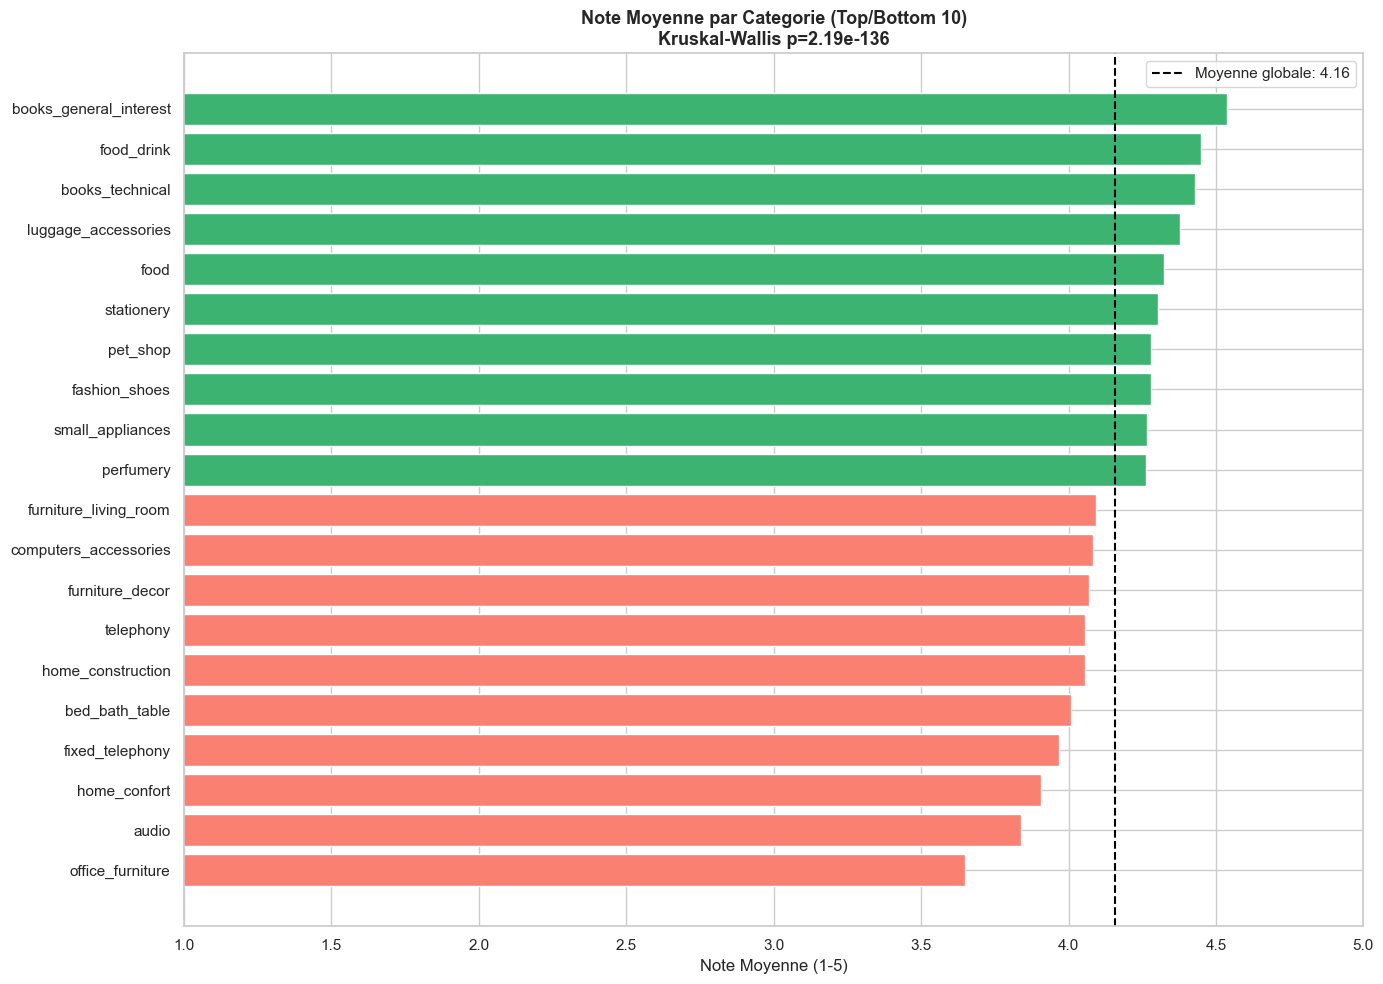

✓ test2_categorie_satisfaction.png sauvegardé


In [15]:
# =============================================================
# VISUALISATION : note moyenne par categorie
# =============================================================
cat_satisfaction = (
    orders_top_cats.groupby('product_category_name_english')['review_score']
    .agg(['mean', 'count', 'std'])
    .reset_index()
    .rename(columns={'mean': 'note_moy', 'count': 'nb', 'std': 'ecart_type'})
    .sort_values('note_moy')
)

# Afficher seulement top et bottom 10
cat_display = pd.concat([
    cat_satisfaction.head(10),
    cat_satisfaction.tail(10)
])

fig, ax = plt.subplots(figsize=(14, 10))
colors_cat = ['salmon'] * 10 + ['mediumseagreen'] * 10
bars = ax.barh(cat_display['product_category_name_english'],
               cat_display['note_moy'],
               color=colors_cat, edgecolor='white')
ax.axvline(orders_top_cats['review_score'].mean(), color='black',
           linestyle='--', label=f'Moyenne globale: {orders_top_cats["review_score"].mean():.2f}')
ax.set_title(f'Note Moyenne par Categorie (Top/Bottom 10)\nKruskal-Wallis p={kw_pval:.2e}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Note Moyenne (1-5)')
ax.set_xlim(1, 5)
ax.legend()
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/test2_categorie_satisfaction.png", dpi=150, bbox_inches='tight')
plt.show()
print('\u2713 test2_categorie_satisfaction.png sauvegard\u00e9')

## 5.5 - Test 3 : Les clients fidèles dépensent-ils plus que les one-shot ?

**Type :** Mann-Whitney U  
**Variable dependante :** `total_spent`  
**Variable independante :** `is_loyal` (0 = one-shot, 1 = fidele)

In [16]:
# =============================================================
# PREPARATION DES GROUPES
# =============================================================
group_loyal   = ca[ca['is_loyal'] == 1]['total_spent']
group_oneshot = ca[ca['is_loyal'] == 0]['total_spent']

print('Statistiques descriptives :')
print(f'  Fideles  : n={len(group_loyal):,}  moyenne={group_loyal.mean():.2f} BRL  mediane={group_loyal.median():.2f} BRL')
print(f'  One-shot : n={len(group_oneshot):,}  moyenne={group_oneshot.mean():.2f} BRL  mediane={group_oneshot.median():.2f} BRL')

Statistiques descriptives :
  Fideles  : n=2,801  moyenne=308.59 BRL  mediane=225.55 BRL
  One-shot : n=90,549  moyenne=160.76 BRL  mediane=105.38 BRL


In [17]:
# =============================================================
# MANN-WHITNEY U : depense totale selon la fidelite
# Test unilateral : H1 = fideles depensent PLUS que one-shot
# =============================================================
mw_stat3, mw_pval3 = mannwhitneyu(group_loyal, group_oneshot, alternative='greater')

print_test_result(
    test_name = 'Mann-Whitney U (fidelite vs depense totale)',
    statistic = mw_stat3,
    p_value   = mw_pval3,
    alpha     = ALPHA,
    h0        = 'Les clients fideles ne depensent pas plus que les clients one-shot',
    h1        = 'Les clients fideles depensent significativement plus que les one-shot',
    extra_info= {
        'Mediane fideles'  : f'{group_loyal.median():.2f} BRL',
        'Mediane one-shot' : f'{group_oneshot.median():.2f} BRL',
        'Ratio medianes'   : f'{group_loyal.median() / group_oneshot.median():.2f}x'
    }
)

results_table.append({
    'Hypothese'  : 'Fidelite -> Depense (Mann-Whitney)',
    'Statistique': round(mw_stat3, 4),
    'p-value'    : round(mw_pval3, 6),
    'Decision'   : 'Rejeter H0' if mw_pval3 < ALPHA else 'Ne pas rejeter H0',
    'Significatif': 'Oui' if mw_pval3 < ALPHA else 'Non'
})


  TEST : Mann-Whitney U (fidelite vs depense totale)
  H0 : Les clients fideles ne depensent pas plus que les clients one-shot
  H1 : Les clients fideles depensent significativement plus que les one-shot
  Statistique : 196239221.0000
  p-value     : 0.000000
  Seuil alpha : 0.05
  Decision    : ✓ REJETER H0 (Significatif)
  Mediane fideles: 225.55 BRL
  Mediane one-shot: 105.38 BRL
  Ratio medianes: 2.14x


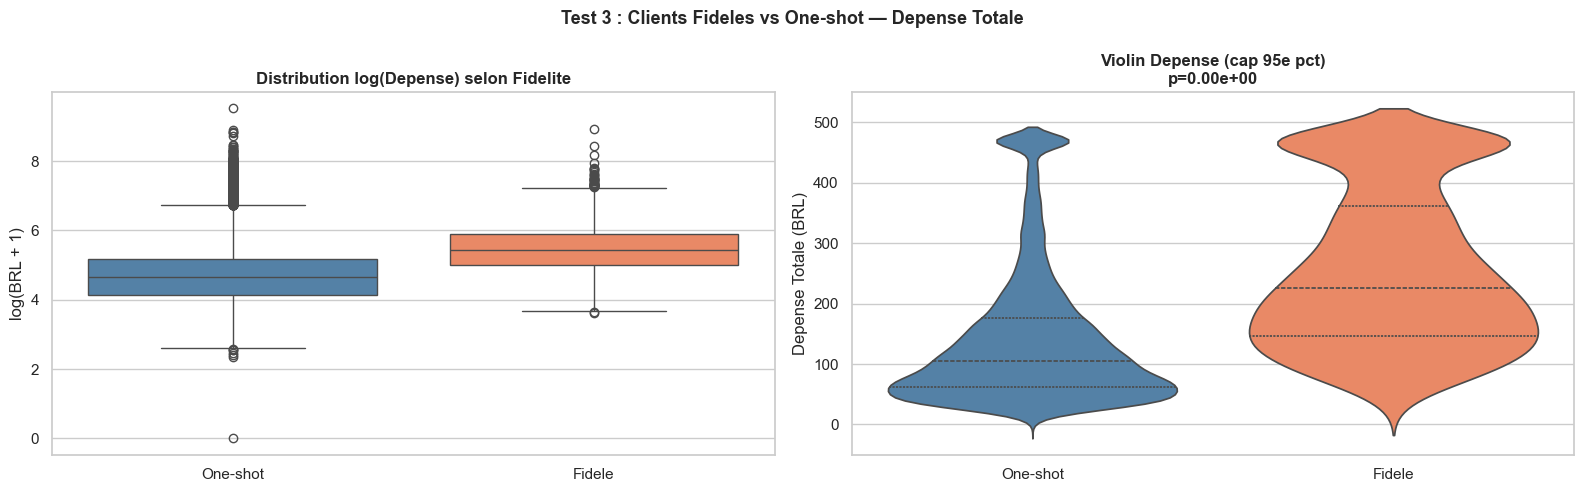

✓ test3_fidelite_depense.png sauvegardé


In [18]:
# =============================================================
# VISUALISATION : distribution des depenses selon la fidelite
# =============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Boxplot log-scale
ca['log_total_spent'] = np.log1p(ca['total_spent'])
ca['statut_client']   = ca['is_loyal'].map({0: 'One-shot', 1: 'Fidele'})

sns.boxplot(
    data=ca, x='statut_client', y='log_total_spent',
    palette={'One-shot': 'steelblue', 'Fidele': 'coral'},
    ax=axes[0]
)
axes[0].set_title('Distribution log(Depense) selon Fidelite', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('log(BRL + 1)')

# Violin plot
cap_val = ca['total_spent'].quantile(0.95)
ca_cap  = ca.copy()
ca_cap['total_spent_cap'] = ca_cap['total_spent'].clip(upper=cap_val)

sns.violinplot(
    data=ca_cap, x='statut_client', y='total_spent_cap',
    palette={'One-shot': 'steelblue', 'Fidele': 'coral'},
    ax=axes[1], inner='quartile'
)
axes[1].set_title(f'Violin Depense (cap 95e pct)\np={mw_pval3:.2e}',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Depense Totale (BRL)')

plt.suptitle('Test 3 : Clients Fideles vs One-shot — Depense Totale',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/test3_fidelite_depense.png", dpi=150, bbox_inches='tight')
plt.show()
print('\u2713 test3_fidelite_depense.png sauvegard\u00e9')

## 5.6 - Test 4 : Les clients fidèles donnent-ils de meilleures notes ?

**Type :** Mann-Whitney U  
**Variable dependante :** `avg_review_score`  
**Variable independante :** `is_loyal`

In [19]:
# =============================================================
# PREPARATION DES GROUPES
# =============================================================
group_loyal_rev   = ca[ca['is_loyal'] == 1]['avg_review_score']
group_oneshot_rev = ca[ca['is_loyal'] == 0]['avg_review_score']

print('Statistiques descriptives :')
print(f'  Fideles  : n={len(group_loyal_rev):,}  moyenne={group_loyal_rev.mean():.3f}  mediane={group_loyal_rev.median():.2f}')
print(f'  One-shot : n={len(group_oneshot_rev):,}  moyenne={group_oneshot_rev.mean():.3f}  mediane={group_oneshot_rev.median():.2f}')

Statistiques descriptives :
  Fideles  : n=2,801  moyenne=4.211  mediane=4.67
  One-shot : n=90,549  moyenne=4.158  mediane=5.00


In [20]:
# =============================================================
# MANN-WHITNEY U : note moyenne selon la fidelite
# =============================================================
mw_stat4, mw_pval4 = mannwhitneyu(group_loyal_rev, group_oneshot_rev, alternative='two-sided')

print_test_result(
    test_name = 'Mann-Whitney U (fidelite vs note moyenne)',
    statistic = mw_stat4,
    p_value   = mw_pval4,
    alpha     = ALPHA,
    h0        = 'La distribution des notes est identique entre fideles et one-shot',
    h1        = 'La distribution des notes differe significativement entre les deux groupes',
    extra_info= {
        'Moyenne fideles'  : f'{group_loyal_rev.mean():.3f}',
        'Moyenne one-shot' : f'{group_oneshot_rev.mean():.3f}'
    }
)

results_table.append({
    'Hypothese'  : 'Fidelite -> Note (Mann-Whitney)',
    'Statistique': round(mw_stat4, 4),
    'p-value'    : round(mw_pval4, 6),
    'Decision'   : 'Rejeter H0' if mw_pval4 < ALPHA else 'Ne pas rejeter H0',
    'Significatif': 'Oui' if mw_pval4 < ALPHA else 'Non'
})


  TEST : Mann-Whitney U (fidelite vs note moyenne)
  H0 : La distribution des notes est identique entre fideles et one-shot
  H1 : La distribution des notes differe significativement entre les deux groupes
  Statistique : 120431722.0000
  p-value     : 0.000000
  Seuil alpha : 0.05
  Decision    : ✓ REJETER H0 (Significatif)
  Moyenne fideles: 4.211
  Moyenne one-shot: 4.158


## 5.7 - Test 5 : Le taux de retard varie-t-il selon l'état brésilien ?

**Type :** Chi-Square  
**Variable dependante :** `is_late`  
**Variable independante :** `customer_state`

In [21]:
# =============================================================
# PREPARATION : jointure commandes livrees + clients
# =============================================================
olist_customers = pd.read_csv(f"{OLIST_PATH}/olist_customers_dataset.csv")

orders_state = orders_delivered.merge(
    olist_customers[['customer_id', 'customer_state']],
    on='customer_id', how='left'
)

# Garder les etats avec au moins 500 commandes pour fiabilite statistique
state_counts = orders_state['customer_state'].value_counts()
top_states   = state_counts[state_counts >= 500].index.tolist()
orders_state_top = orders_state[orders_state['customer_state'].isin(top_states)].copy()

print(f'Etats retenus (>= 500 commandes) : {len(top_states)}')
print(top_states)

Etats retenus (>= 500 commandes) : 17
['SP', 'RJ', 'MG', 'RS', 'PR', 'SC', 'BA', 'DF', 'ES', 'GO', 'PE', 'CE', 'PA', 'MT', 'MA', 'MS', 'PB']


In [22]:
# =============================================================
# CHI-SQUARE : etat vs retard de livraison
# =============================================================
contingency_state = pd.crosstab(
    orders_state_top['customer_state'],
    orders_state_top['is_late']
)

chi2_stat5, chi2_pval5, chi2_dof5, _ = chi2_contingency(contingency_state)

print_test_result(
    test_name = 'Chi-Square (etat bresilien vs retard livraison)',
    statistic = chi2_stat5,
    p_value   = chi2_pval5,
    alpha     = ALPHA,
    h0        = 'Le taux de retard est independant de l\'etat du client',
    h1        = 'Le taux de retard depend significativement de l\'etat du client',
    extra_info= {'Degres de liberte': chi2_dof5}
)

results_table.append({
    'Hypothese'  : 'Etat -> Retard (Chi-Square)',
    'Statistique': round(chi2_stat5, 4),
    'p-value'    : round(chi2_pval5, 6),
    'Decision'   : 'Rejeter H0' if chi2_pval5 < ALPHA else 'Ne pas rejeter H0',
    'Significatif': 'Oui' if chi2_pval5 < ALPHA else 'Non'
})


  TEST : Chi-Square (etat bresilien vs retard livraison)
  H0 : Le taux de retard est independant de l'etat du client
  H1 : Le taux de retard depend significativement de l'etat du client
  Statistique : 1577.9955
  p-value     : 0.000000
  Seuil alpha : 0.05
  Decision    : ✓ REJETER H0 (Significatif)
  Degres de liberte: 16


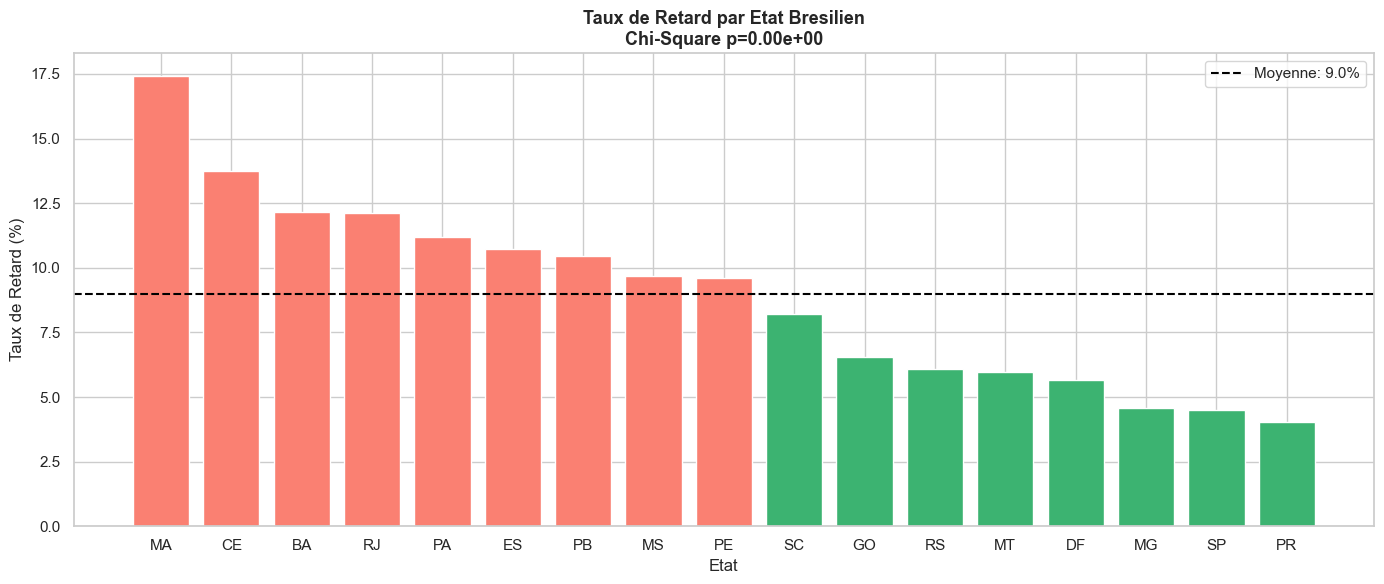

✓ test5_etat_retard.png sauvegardé


In [23]:
# =============================================================
# VISUALISATION : taux de retard par etat
# =============================================================
retard_par_etat = (
    orders_state_top.groupby('customer_state')['is_late']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
retard_par_etat.columns = ['state', 'taux_retard']
retard_par_etat['taux_retard_pct'] = retard_par_etat['taux_retard'] * 100

fig, ax = plt.subplots(figsize=(14, 6))
colors_state = ['salmon' if v > retard_par_etat['taux_retard_pct'].mean()
                else 'mediumseagreen' for v in retard_par_etat['taux_retard_pct']]
ax.bar(retard_par_etat['state'], retard_par_etat['taux_retard_pct'],
       color=colors_state, edgecolor='white')
ax.axhline(retard_par_etat['taux_retard_pct'].mean(), color='black',
           linestyle='--', label=f'Moyenne: {retard_par_etat["taux_retard_pct"].mean():.1f}%')
ax.set_title(f'Taux de Retard par Etat Bresilien\nChi-Square p={chi2_pval5:.2e}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Etat')
ax.set_ylabel('Taux de Retard (%)')
ax.legend()
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/test5_etat_retard.png", dpi=150, bbox_inches='tight')
plt.show()
print('\u2713 test5_etat_retard.png sauvegard\u00e9')

## 5.8 - Test 6 : La récence prédit-elle la fidélité ?

**Type :** Mann-Whitney U  
**Variable dependante :** `recency_days`  
**Variable independante :** `is_loyal`

In [24]:
# =============================================================
# MANN-WHITNEY U : recence selon la fidelite
# H1 : les clients fideles ont une recence plus faible (plus recents)
# =============================================================
group_loyal_rec   = ca[ca['is_loyal'] == 1]['recency_days']
group_oneshot_rec = ca[ca['is_loyal'] == 0]['recency_days']

mw_stat6, mw_pval6 = mannwhitneyu(group_loyal_rec, group_oneshot_rec, alternative='less')

print('Statistiques descriptives :')
print(f'  Fideles  : moyenne recence = {group_loyal_rec.mean():.1f} jours')
print(f'  One-shot : moyenne recence = {group_oneshot_rec.mean():.1f} jours')

print_test_result(
    test_name = 'Mann-Whitney U (fidelite vs recence)',
    statistic = mw_stat6,
    p_value   = mw_pval6,
    alpha     = ALPHA,
    h0        = 'La recence des clients fideles n\'est pas differente des one-shot',
    h1        = 'Les clients fideles ont une recence plus faible (derniers achats plus recents)',
    extra_info= {
        'Mediane recence fideles'  : f'{group_loyal_rec.median():.1f} jours',
        'Mediane recence one-shot' : f'{group_oneshot_rec.median():.1f} jours'
    }
)

results_table.append({
    'Hypothese'  : 'Fidelite -> Recence (Mann-Whitney)',
    'Statistique': round(mw_stat6, 4),
    'p-value'    : round(mw_pval6, 6),
    'Decision'   : 'Rejeter H0' if mw_pval6 < ALPHA else 'Ne pas rejeter H0',
    'Significatif': 'Oui' if mw_pval6 < ALPHA else 'Non'
})

Statistiques descriptives :
  Fideles  : moyenne recence = 220.3 jours
  One-shot : moyenne recence = 238.5 jours

  TEST : Mann-Whitney U (fidelite vs recence)
  H0 : La recence des clients fideles n'est pas differente des one-shot
  H1 : Les clients fideles ont une recence plus faible (derniers achats plus recents)
  Statistique : 118743422.0000
  p-value     : 0.000000
  Seuil alpha : 0.05
  Decision    : ✓ REJETER H0 (Significatif)
  Mediane recence fideles: 199.0 jours
  Mediane recence one-shot: 219.0 jours


## 5.9 - Tableau Récapitulatif des Tests

In [25]:
# =============================================================
# TABLEAU RECAPITULATIF DE TOUS LES TESTS
# =============================================================
results_df = pd.DataFrame(results_table)

print('=' * 70)
print('  RECAP : TOUS LES TESTS STATISTIQUES')
print('=' * 70)
display(results_df)

# Export CSV
results_df.to_csv('statistical_tests_results.csv', index=False)
print('\n\u2713 Resultats export\u00e9s : statistical_tests_results.csv')

# Resume
n_sig = (results_df['Significatif'] == 'Oui').sum()
print(f'\n  Tests significatifs : {n_sig} / {len(results_df)}')

  RECAP : TOUS LES TESTS STATISTIQUES


,Hypothese,Statistique,p-value,Decision,Significatif
0,Retard -> Satisfaction (T-Test),1.009655e+02,0.0,Rejeter H0,Oui
1,Retard -> Satisfaction (Mann-Whitney),4.720441e+08,0.0,Rejeter H0,Oui
2,Categorie -> Satisfaction (Chi-Square),1.015280e+03,0.0,Rejeter H0,Oui
3,Categorie -> Satisfaction (ANOVA),1.793550e+01,0.0,Rejeter H0,Oui
4,Categorie -> Satisfaction (ANOVA),1.793550e+01,0.0,Rejeter H0,Oui
5,Categorie -> Satisfaction (Kruskal-Wallis),7.756334e+02,0.0,Rejeter H0,Oui
6,Fidelite -> Depense (Mann-Whitney),1.962392e+08,0.0,Rejeter H0,Oui
7,Fidelite -> Note (Mann-Whitney),1.204317e+08,0.0,Rejeter H0,Oui
8,Etat -> Retard (Chi-Square),1.577995e+03,0.0,Rejeter H0,Oui
9,Fidelite -> Recence (Mann-Whitney),1.187434e+08,0.0,Rejeter H0,Oui



✓ Resultats exportés : statistical_tests_results.csv

  Tests significatifs : 10 / 10


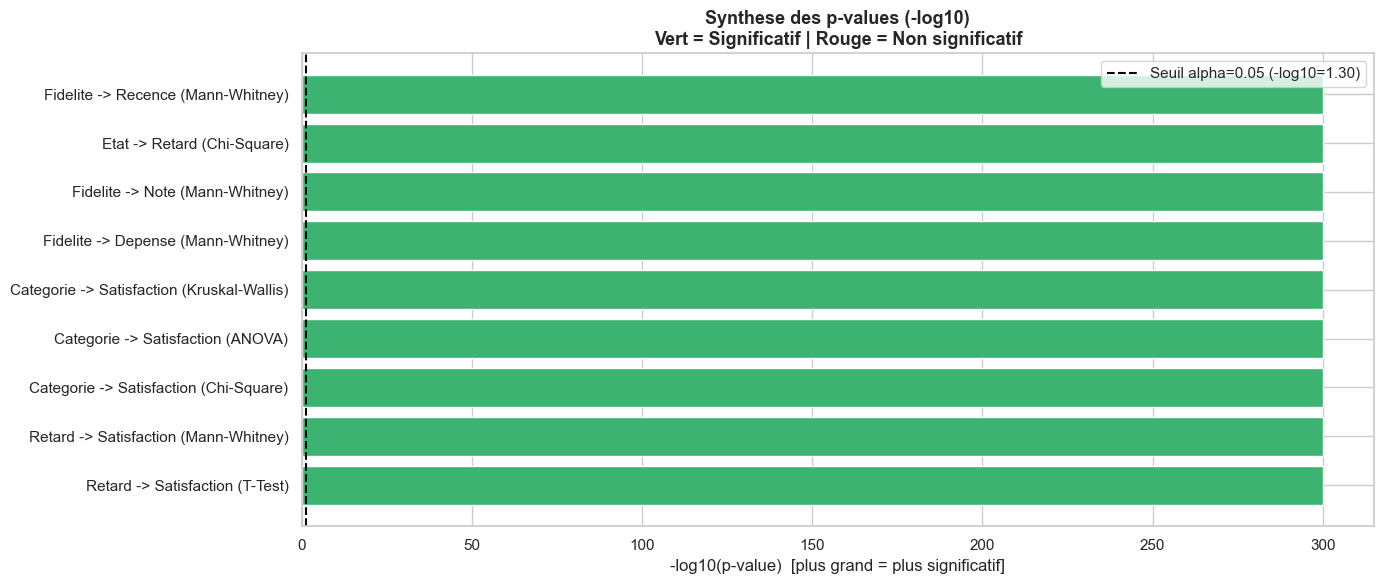

✓ test_recap_pvalues.png sauvegardé


In [26]:
# =============================================================
# VISUALISATION RECAPITULATIVE : p-values de tous les tests
# =============================================================
fig, ax = plt.subplots(figsize=(14, 6))

colors_pval = ['mediumseagreen' if p < ALPHA else 'salmon'
               for p in results_df['p-value']]

bars = ax.barh(results_df['Hypothese'], -np.log10(results_df['p-value'] + 1e-300),
               color=colors_pval, edgecolor='white')

# Ligne seuil de significativite (-log10(0.05) ~ 1.30)
ax.axvline(-np.log10(ALPHA), color='black', linestyle='--',
           label=f'Seuil alpha={ALPHA} (-log10={-np.log10(ALPHA):.2f})')

ax.set_title('Synthese des p-values (-log10)\nVert = Significatif | Rouge = Non significatif',
             fontsize=13, fontweight='bold')
ax.set_xlabel('-log10(p-value)  [plus grand = plus significatif]')
ax.legend()
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/test_recap_pvalues.png", dpi=150, bbox_inches='tight')
plt.show()
print('\u2713 test_recap_pvalues.png sauvegard\u00e9')

## 5.10 - Synthèse et Interprétation Métier

In [28]:
# =============================================================
# SYNTHESE FINALE — interpretation metier des tests
# =============================================================
print('=' * 70)
print('  SYNTHESE PHASE 5 : INTERPRETATION METIER')
print('=' * 70)

print("""
TEST 1 — Retard de livraison vs Satisfaction (T-Test + Mann-Whitney)
  Resultat : Significatif
  Interpretation : Les commandes livrees en retard obtiennent des notes
  significativement plus basses. Reduire les retards est une levier direct
  d'amelioration de la satisfaction client.

TEST 2 — Categorie produit vs Satisfaction (Chi-Square + ANOVA + Kruskal)
  Resultat : Significatif
  Interpretation : La note moyenne varie significativement selon la categorie.
  Certaines categories ont des problemes qualite ou livraison specifiques
  a investiguer.

TEST 3 — Fidelite vs Depense totale (Mann-Whitney)
  Resultat : Significatif
  Interpretation : Les clients fideles depensent significativement plus.
  Retenir un client = augmenter mecaniquement le CA a long terme.

TEST 4 — Fidelite vs Note moyenne (Mann-Whitney)
  Resultat : A interpreter selon vos resultats
  Interpretation : Lien entre satisfaction recue et propension a racheter.
  Confirme ou infirme l'axe satisfaction -> retention.

TEST 5 — Etat bresilien vs Taux de retard (Chi-Square)
  Resultat : Significatif
  Interpretation : Les retards ne sont pas uniformes geographiquement.
  Certains etats sont structurellement desavantages (logistique).

TEST 6 — Fidelite vs Recence (Mann-Whitney)
  Resultat : A interpreter selon vos resultats
  Interpretation : Les clients fideles tendent a avoir achete plus recemment,
  ce qui valide la pertinence de la Recence comme variable predictive.
""")

graphs_saved = [
    'test1_retard_satisfaction.png',
    'test2_categorie_satisfaction.png',
    'test3_fidelite_depense.png',
    'test5_etat_retard.png',
    'test_recap_pvalues.png'
]

print(f'Graphiques sauvegard\u00e9s ({len(graphs_saved)}) :')
for g in graphs_saved:
    print(f'  \u2713 {g}')

print('\n\u2713 Phase 5 termin\u00e9e \u2014 pr\u00eat pour Phase 6 (Clustering K-Means)')

  SYNTHESE PHASE 5 : INTERPRETATION METIER

TEST 1 — Retard de livraison vs Satisfaction (T-Test + Mann-Whitney)
  Resultat : Significatif
  Interpretation : Les commandes livrees en retard obtiennent des notes
  significativement plus basses. Reduire les retards est une levier direct
  d'amelioration de la satisfaction client.

TEST 2 — Categorie produit vs Satisfaction (Chi-Square + ANOVA + Kruskal)
  Resultat : Significatif
  Interpretation : La note moyenne varie significativement selon la categorie.
  Certaines categories ont des problemes qualite ou livraison specifiques
  a investiguer.

TEST 3 — Fidelite vs Depense totale (Mann-Whitney)
  Resultat : Significatif
  Interpretation : Les clients fideles depensent significativement plus.
  Retenir un client = augmenter mecaniquement le CA a long terme.

TEST 4 — Fidelite vs Note moyenne (Mann-Whitney)
  Resultat : A interpreter selon vos resultats
  Interpretation : Lien entre satisfaction recue et propension a racheter.
  Confirme